# Task 4: SAM Classification and Sensor Calibration
This notebook implements the Spectral Angle Mapper (SAM) for airborne data classification and performs a radiometric calibration of Sentinel-2 data using the airborne data as a reference.

## Step 1: Imports and Configuration
We load libraries for hyperspectral processing, STAC discovery, and statistical analysis.

In [ ]:
# !uv pip install rasterio spectral pystac_client planetary_computer

Resolved 31 packages in 359ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 56ms
 + spectral==0.24


In [16]:
from datetime import datetime, timedelta
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import transform
from rasterio.windows import from_bounds
import spectral.io.envi as envi
from pystac_client import Client
import planetary_computer
from scipy.stats import linregress

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## Loading Airborne Data

In [8]:
LAB_5_DIR = Path().cwd() / "lab_5"
BASE_DIR = LAB_5_DIR / "data" / "you-shall-not-pass" / "Obrazy lotnicze"
print(BASE_DIR)
hdr_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr'
bsq_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.bsq'

E:\github_repos\eolabs\lab_5\data\you-shall-not-pass\Obrazy lotnicze


In [11]:
if hdr_path.exists():
    img = envi.open(hdr_path)
    print(f"Opened airborne cube: {hdr_path.name}")
    print(f"Shape: {img.shape}")
    
    # Since the cubes are large and memory overload is totally possible
    # only a subset is loaded
    cy, cx = img.nrows // 2, img.ncols // 2
    r_start, r_end = cy - 250, cy + 250
    c_start, c_end = cx - 250, cx + 250
    airborne_cube = img.read_subregion((r_start, r_end), (c_start, c_end))
    
    # Get wavelengths
    wavelengths = np.array([float(x) for x in img.metadata['wavelength']])
    print(f"Loaded subset shape: {airborne_cube.shape}")
else:
    print("Airborne data not found at expected path.")

Opened airborne cube: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Shape: (4300, 2001, 456)
Loaded subset shape: (500, 500, 456)


## Description of Methods

Different land cover types (water, forest, green areas) are loaded as reference spectra for SAM.

In [12]:
sig_dir = LAB_5_DIR / "spectral_signatures"
sig_files = list(sig_dir.glob('*.csv'))

spectra = {}
for f in sig_files:
    class_name = f.stem.rstrip('1234567890')
    df = pd.read_csv(f)
    if class_name not in spectra: spectra[class_name] = []
    spectra[class_name].append(df['value'].values)

# Calculate mean spectra for each class
reference_spectra = {k: np.nanmean(v, axis=0) for k, v in spectra.items()}
print(f"Reference classes: {list(reference_spectra.keys())}")

Reference classes: ['forest', 'green', 'water']


## Spectral Angle Mapper (SAM)

SAM calculates the spectral similarity between a reference spectrum and each pixel by computing the angle between them in a multidimensional spectral space. 

Smaller angles indicate higher similarity.

In this case SAM can distinguish between different types of water, which can show the contamination

It's calculated, because while the same pixel can appear brighter/darker based on conditions, but it will not change the spectral signature significantly, which can help identify different materials

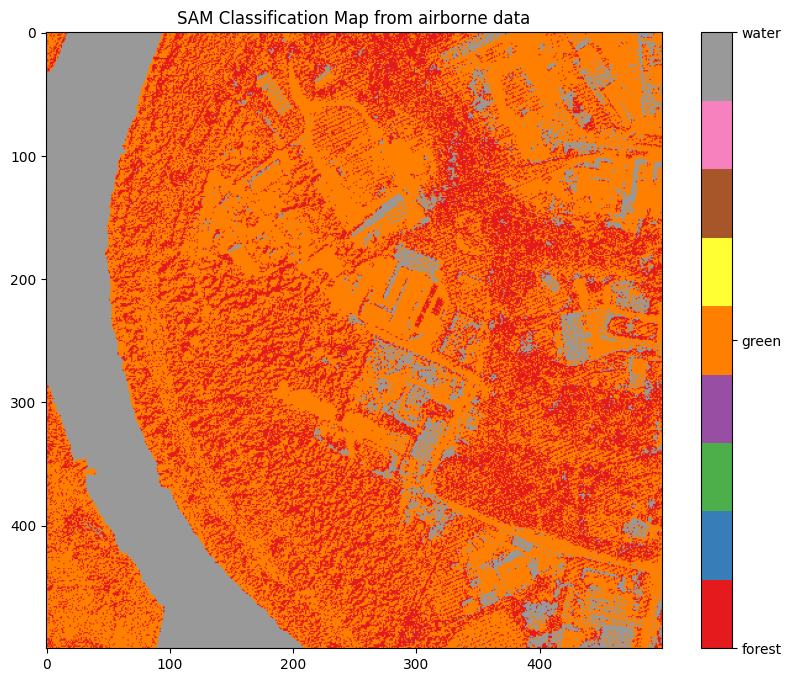

In [21]:
def compute_sam(hypercube, ref_spectrum):
    # ref_spectrum might need interpolation if band counts differ
    if len(ref_spectrum) != hypercube.shape[2]:
        ref_spectrum = np.interp(
            np.linspace(0, 1, hypercube.shape[2]), 
            np.linspace(0, 1, len(ref_spectrum)), 
            ref_spectrum
        )
    
    dot_product = np.sum(hypercube * ref_spectrum, axis=2)
    norm_cube = np.sqrt(np.sum(hypercube**2, axis=2))
    norm_ref = np.sqrt(np.sum(ref_spectrum**2))
    cos_theta = dot_product / (norm_cube * norm_ref + 1e-8)
    # clip values to arcos range to avoid numerical issues
    return np.arccos(np.clip(cos_theta, -1.0, 1.0))

# each class is applied the SAM
sam_maps = {k: compute_sam(airborne_cube, ref) for k, ref in reference_spectra.items()}

# minimal angle is used to classify pixels
class_names = list(sam_maps.keys())
stacked_angles = np.stack([sam_maps[k] for k in class_names], axis=-1)
classification = np.argmin(stacked_angles, axis=-1)

# plot the SAM classification map
plt.figure(figsize=(10, 8))
im = plt.imshow(classification, cmap='Set1')
cbar = plt.colorbar(im, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
plt.title('SAM Classification Map from airborne data')
plt.show()

As it can be seen there are the three classes visible, the colorbar is a bit off (the intuition is not your friend here, but it actually got the classses right)

## Fetch Sentinel-2 Data for aquisition date

**2025-07-17**

In [14]:
import certifi
import os

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [22]:
# Bounding box approx from Polish CS2000 Z6 (Odra River)
bbox = [14.4, 52.8, 14.8, 53.2]
acq_date = "2025-06-17"

target_date = datetime.strptime(acq_date, "%Y-%m-%d")
start_date = (target_date - timedelta(days=7)).strftime("%Y-%m-%d")
end_date = (target_date + timedelta(days=7)).strftime("%Y-%m-%d")

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", 
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=f"{start_date}/{end_date}",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = list(search.items())
if items:
    best_item = items[0]
    print(f"Found Sentinel-2 item: {best_item.id}")
    
    # Access bands for RGB + NIR
    assets = best_item.assets
    b_blue = assets['B02'].href
    b_green = assets['B03'].href
    b_red = assets['B04'].href
    b_nir = assets['B08'].href
    
    with rasterio.open(b_red) as src:
        s2_red = src.read(1, out_shape=(500, 500)).astype('float32') / 10000.0
    print("Loaded resampled Sentinel-2 Red band.")
else:
    print("No Sentinel-2 image found for this date.")

Found Sentinel-2 item: S2C_MSIL2A_20250621T100611_R022_T33UVV_20250623T084315
Loaded resampled Sentinel-2 Red band.


## Calibrate Sentinel-2 using Airborne Data

To calibrate the satellite data, we use the airborne hyperspectral data as a high-resolution reference. We aggregate the airborne data to match the Sentinel-2 spectral response and spatial resolution, then compute a linear regression to find the gain and offset.

Calibration parameters: gain=0.0840, offset=0.0503, R²=0.0042


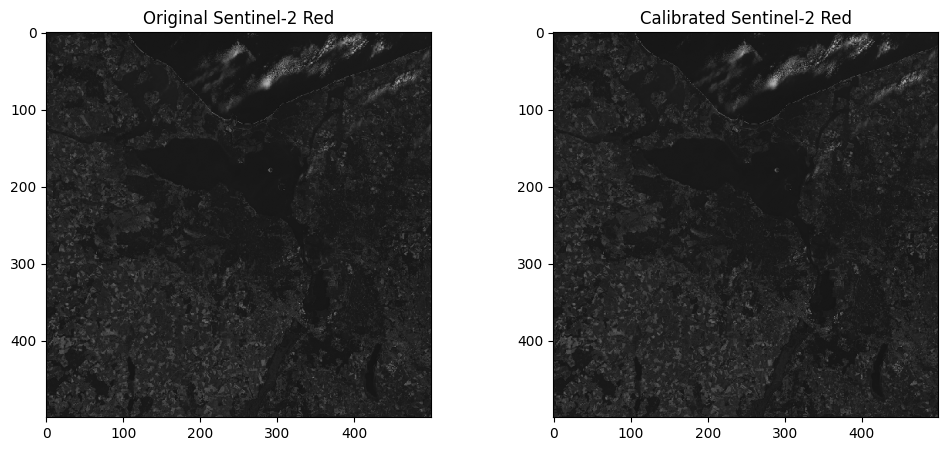

In [23]:
# 1. Extract Red band from airborne cube (approx. 665 nm)
# The same method that was explained in exercise 3
red_idx = np.argmin(np.abs(wavelengths - 665))
airborne_red = airborne_cube[:, :, red_idx]

# 2. Resample airborne Red to match S2 (simple aggregation)
# (Assuming airborne is 1m and S2 is 10m, we aggregate 10x10 blocks)
h, w = airborne_red.shape
airborne_red_10m = airborne_red[:h//10*10, :w//10*10].reshape(h//10, 10, w//10, 10).mean(axis=(1, 3))

# 3. Crop S2 to match the airborne subset extent (approximate)
# this is done to have the same dimensions for both datasets
s2_subset = s2_red[:airborne_red_10m.shape[0], :airborne_red_10m.shape[1]]

# 4. Perform Linear Regression for Calibration
# please note that only non-nan values are used
mask = (airborne_red_10m > 0) & (s2_subset > 0)
slope, intercept, r_value, p_value, std_err = linregress(s2_subset[mask], airborne_red_10m[mask])

print(f"Calibration parameters: gain={slope:.4f}, offset={intercept:.4f}, R²={r_value**2:.4f}")

# 5. Apply Calibration
s2_calibrated = s2_red * slope + intercept

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(s2_red, cmap='gray')
plt.title('Original Sentinel-2 Red')
plt.subplot(1, 2, 2)
plt.imshow(s2_calibrated, cmap='gray')
plt.title('Calibrated Sentinel-2 Red')
plt.show()

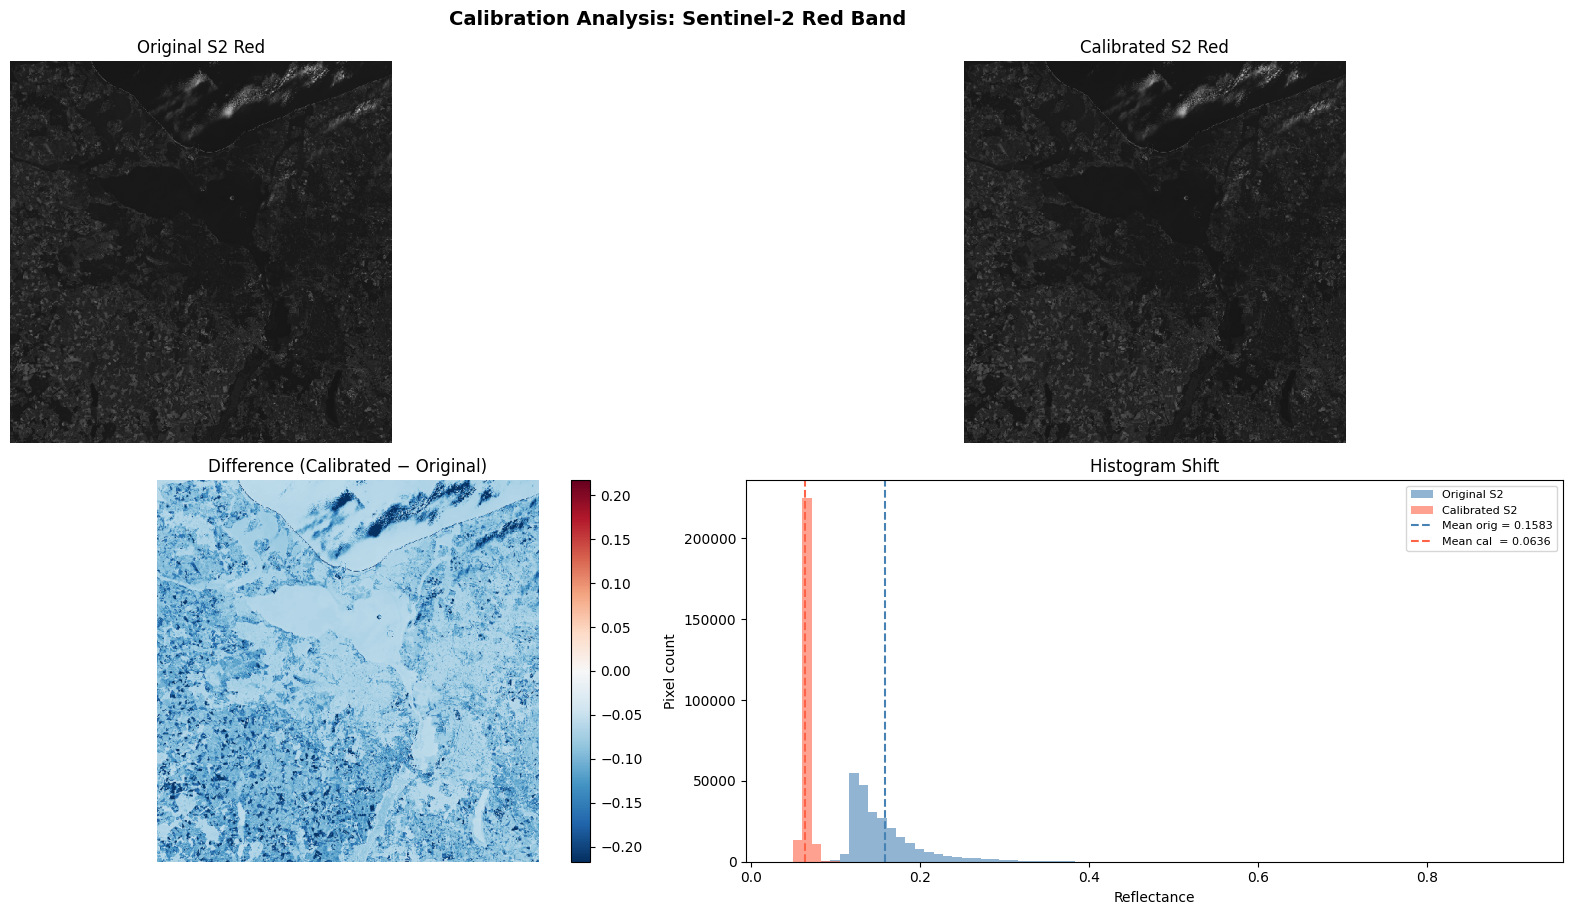

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Calibration Analysis: Sentinel-2 Red Band', fontsize=14, fontweight='bold')

# Original S2
axes[0, 0].imshow(s2_red, cmap='gray')
axes[0, 0].set_title('Original S2 Red')
axes[0, 0].axis('off')

# Calibrated S2
axes[0, 1].imshow(s2_calibrated, cmap='gray')
axes[0, 1].set_title('Calibrated S2 Red')
axes[0, 1].axis('off')

# Difference map (calibrated - original), i.e. the spatial shift
diff = s2_calibrated - s2_red
vmax = np.nanpercentile(np.abs(diff), 98)  # symmetric colorbar, robust to outliers
im = axes[1, 0].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1, 0].set_title('Difference (Calibrated − Original)')
axes[1, 0].axis('off')
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Overlapping histograms
flat_orig = s2_red[s2_red > 0].ravel()
flat_cal  = s2_calibrated[s2_calibrated > 0].ravel()

bins = np.linspace(
    min(flat_orig.min(), flat_cal.min()),
    max(flat_orig.max(), flat_cal.max()),
    80
)
axes[1, 1].hist(flat_orig, bins=bins, alpha=0.6, color='steelblue', label='Original S2')
axes[1, 1].hist(flat_cal,  bins=bins, alpha=0.6, color='tomato',    label='Calibrated S2')
axes[1, 1].axvline(np.nanmean(flat_orig), color='steelblue', linestyle='--', linewidth=1.5,
                   label=f'Mean orig = {np.nanmean(flat_orig):.4f}')
axes[1, 1].axvline(np.nanmean(flat_cal),  color='tomato',    linestyle='--', linewidth=1.5,
                   label=f'Mean cal  = {np.nanmean(flat_cal):.4f}')
axes[1, 1].set_title('Histogram Shift')
axes[1, 1].set_xlabel('Reflectance')
axes[1, 1].set_ylabel('Pixel count')
axes[1, 1].legend(fontsize=8)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

The difference is not visible due to matplotlib's automatic scaling.